IMPORT LIBRARIES

In [82]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# SMOTE
from imblearn.over_sampling import SMOTE

LOAD DATASET

In [83]:
df = pd.read_csv("Final_retention_augmented_dataset.csv")

print(df.shape)
df.head()

(4424, 50)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,absences,famsup,failures,freetime,goout,raisedhands,VisITedResources,AnnouncementsView,Discussion,StudentAbsenceDays
0,1,17,5,171,1,1,122.0,1,19,12,...,2,yes,0,4,3,29,97,19,8,Above-7
1,1,15,1,9254,1,1,160.0,1,1,3,...,2,no,0,3,3,77,18,65,13,Under-7
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,no,2,3,3,81,13,98,7,Under-7
3,1,17,2,9773,1,1,122.0,1,38,37,...,18,yes,0,3,3,9,7,74,93,Under-7
4,2,39,1,8014,0,1,100.0,1,37,38,...,10,no,0,3,3,15,98,72,80,Under-7


DATA UNDERSTANDING

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 50 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [85]:
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,traveltime,studytime,absences,failures,freetime,goout,raisedhands,VisITedResources,AnnouncementsView,Discussion
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,1.419078,2.042043,6.117089,0.324141,3.243445,3.089964,47.962929,54.876582,38.852170,44.354430
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.662457,0.854849,8.329216,0.731572,0.988152,1.108228,30.737325,33.110400,26.605921,27.363598
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,1.000000,1.000000,0.000000,0.000000,3.000000,2.000000,19.000000,20.000000,15.000000,20.000000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,1.000000,2.000000,4.000000,0.000000,3.000000,3.000000,50.000000,65.000000,35.000000,40.000000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,2.000000,2.000000,8.000000,0.000000,4.000000,4.000000,78.000000,84.000000,59.000000,70.000000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,4.000000,4.000000,75.000000,3.000000,5.000000,5.000000,100.000000,99.000000,98.000000,99.000000


MISSING VALUES HANDLING

In [86]:
df.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance\t,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


Fill missing values

In [87]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Numerical → mean
imputer_num = SimpleImputer(strategy='mean')
df[num_cols] = imputer_num.fit_transform(df[num_cols])

# Categorical → most frequent
imputer_cat = SimpleImputer(strategy='most_frequent')
df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

DUPLICATE REMOVAL

In [88]:
df.drop_duplicates(inplace=True)

Remove repeated rows

FEATURE VISUALIZATION

Target Distribution

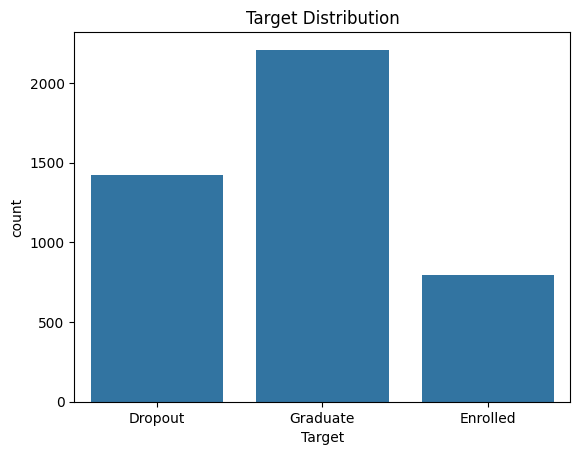

In [89]:
sns.countplot(x='Target', data=df)
plt.title("Target Distribution")
plt.show()

Graduate → highest
Dropout → medium
Enrolled → lowest

The dataset shows a class imbalance among the target categories. The majority of students belong to the "Graduate" class, followed by "Dropout", while the "Enrolled" category has the lowest representation.

This imbalance indicates that the model may become biased toward predicting the majority class. Therefore, techniques such as SMOTE are necessary to balance the dataset and improve model performance, especially for minority classes like "Enrolled".

Numerical Features Distribution

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


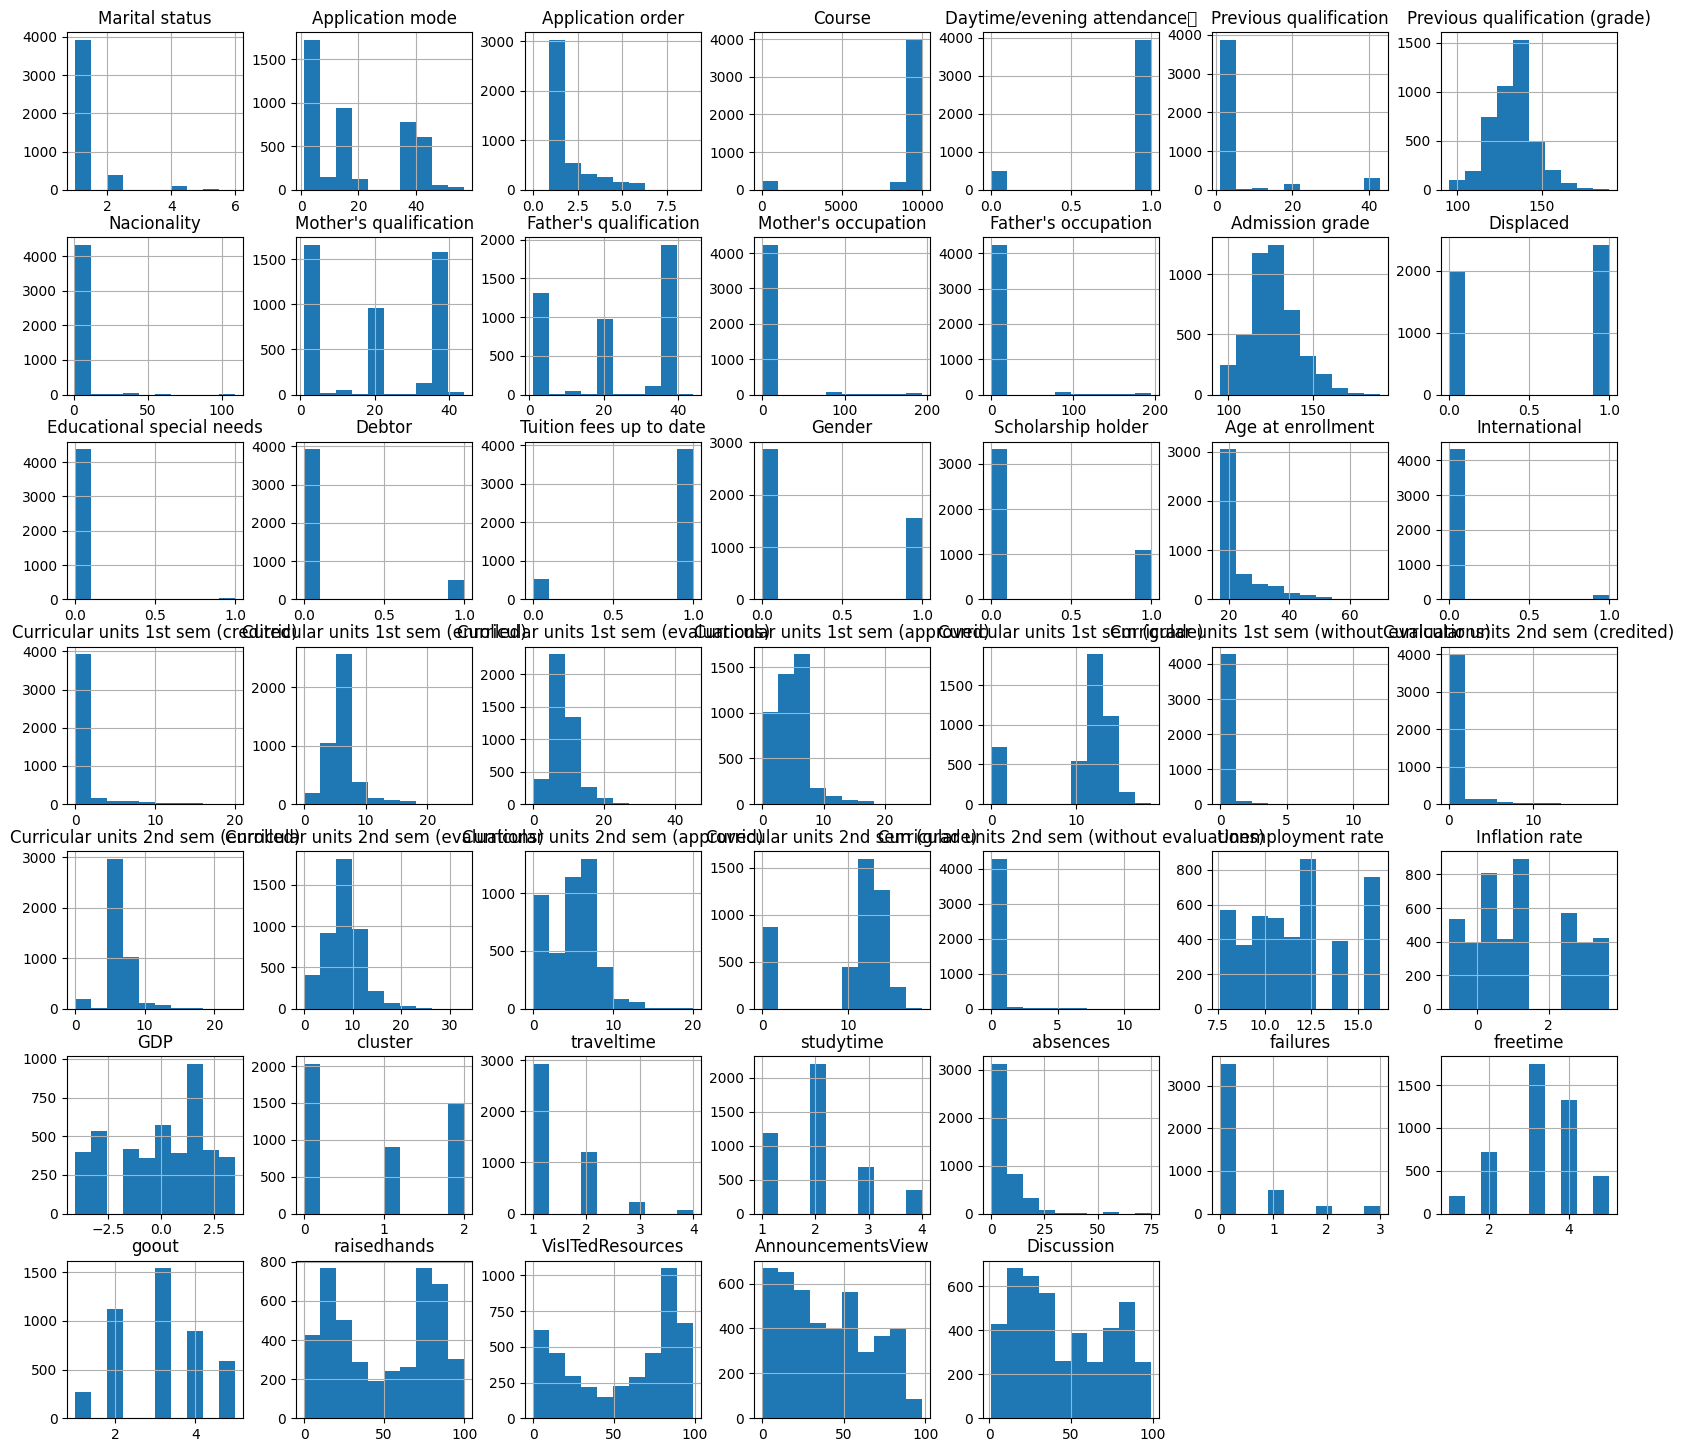

In [90]:
df.hist(figsize=(20,18))
plt.show()

Boxplot (Outliers Detection)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


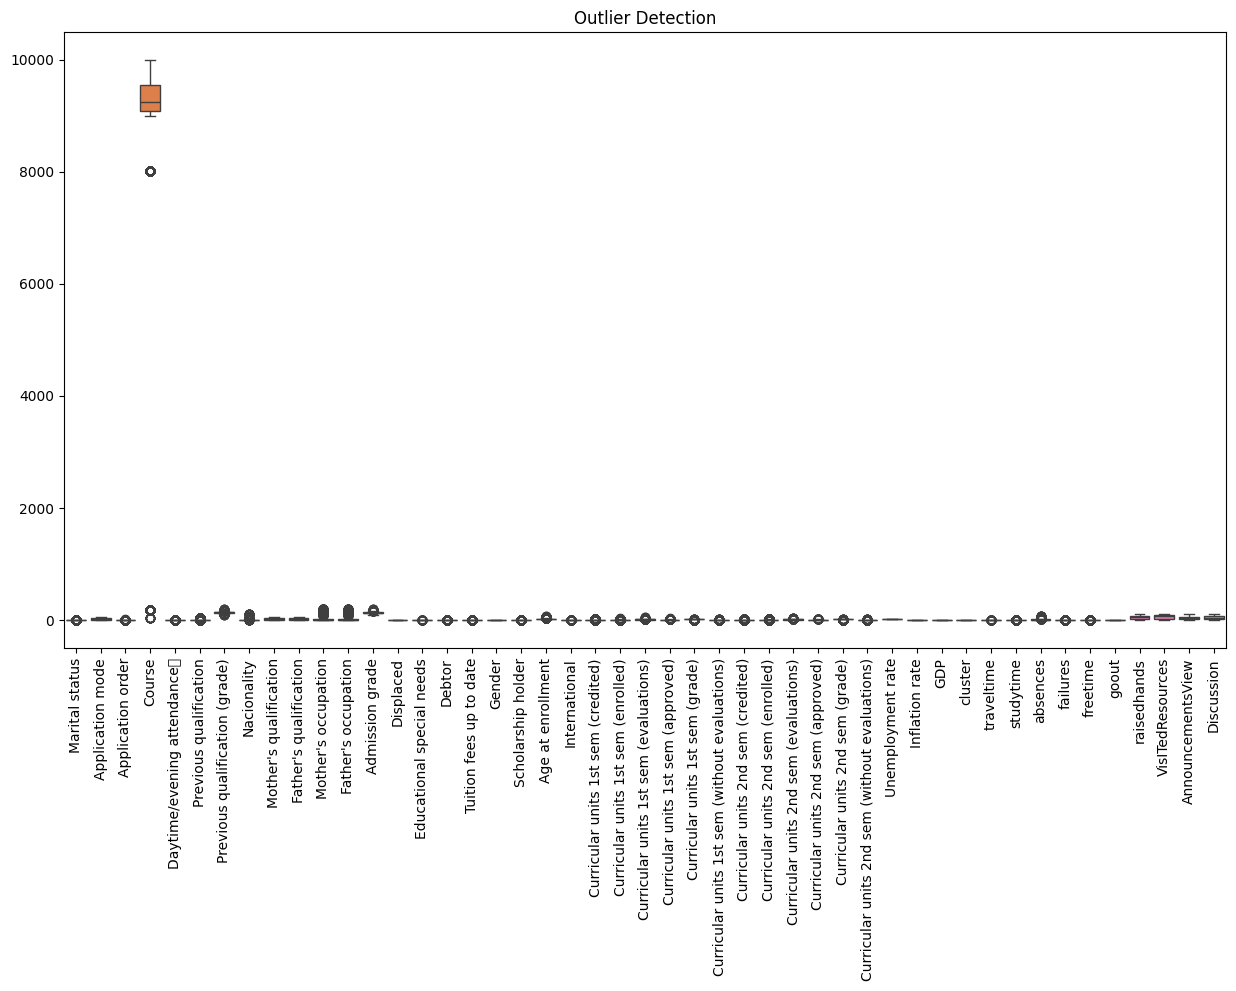

In [91]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()

Course feature → very large values (~8000–10000)
Absences, raisedhands → outliers

The Course feature shows extremely high values (around 8000–10000), which dominate the scale of the plot. This indicates that the feature is encoded as categorical IDs rather than meaningful numerical values.

Due to this large scale difference, most other features appear compressed near zero, making it difficult to visually interpret their distributions.

Several features such as:

Absences
Raised hands
Visited resources
show visible outliers, indicating variability in student behavior.
Academic features (grades, approvals) appear more consistently distributed with fewer extreme outliers.

Correlation Heatmap

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


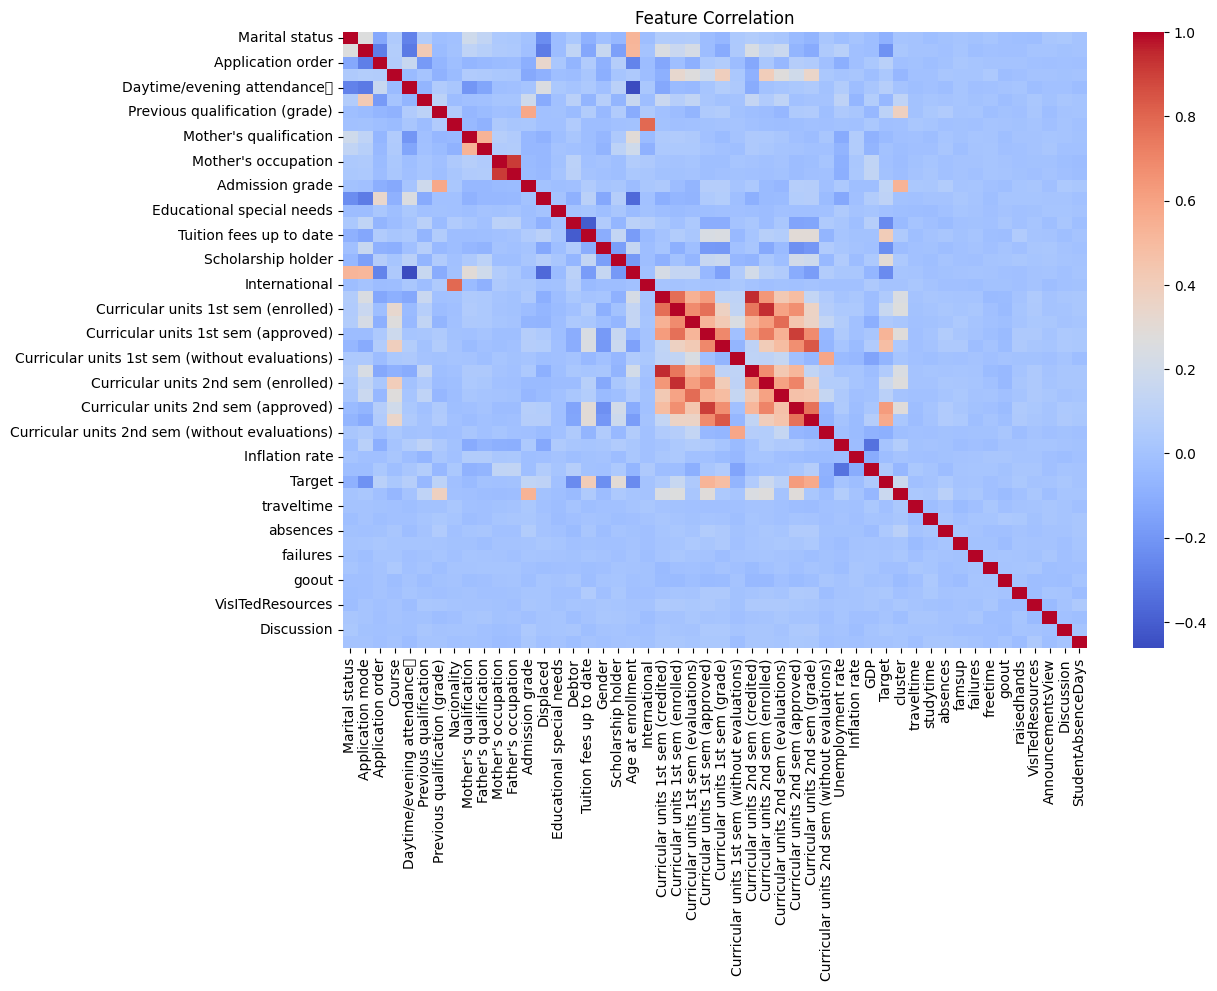

In [92]:
from sklearn.preprocessing import LabelEncoder

# Make a copy of the dataframe to avoid modifying the original df for subsequent operations if needed
df_encoded = df.copy()

# Identify categorical columns that are still objects
cat_cols_for_encoding = df_encoded.select_dtypes(include=['object']).columns

# Apply Label Encoding to each categorical column
for col in cat_cols_for_encoding:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

Red -  Strong positive correlation (+1)
Blue - Negative correlation (-1)       
Light - Weak or no correlation (≈ 0)     


STRONG CORRELATION CLUSTER

Curricular units 1st sem (enrolled)
Curricular units 1st sem (approved)
Curricular units 1st sem (grade)
Curricular units 2nd sem (enrolled)
Curricular units 2nd sem (approved)
Curricular units 2nd sem (grade)

WEAK CORRELATION

Gender
Nationality
Parents' education
Marital status

BEHAVIORAL FEATURES
absences
raisedhands
VisITedResources
Discussion


MOST IMPORTANT TAKEAWAYS
1. Academic features dominate
Strongest predictors

2. Financial features matter
Tuition fees → important

3. Behavioral features help
Moderate contribution

4. Demographic features weak
Minimal impact





### Correlation Heatmap Analysis

- The heatmap shows pairwise correlations between all features.

- A strong positive correlation is observed among academic performance features such as:
  - Curricular units (enrolled, approved, grade) across semesters.

- This indicates that students who perform well in one semester tend to perform well in subsequent semesters.

- The target variable shows moderate correlation with academic and financial features, indicating their influence on student outcomes.

- Behavioral features such as absences, raised hands, and resource visits show moderate correlation, suggesting partial influence.

- Demographic features (e.g., gender, nationality) show weak or negligible correlation, indicating limited predictive power.

- High correlation among academic features suggests redundancy, which can be addressed through feature selection.

- Overall, academic performance is the strongest predictor of student retention, followed by financial and engagement factors.

ENCODE CATEGORICAL VARIABLES

In [93]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

DEFINE FEATURES

In [94]:
X = df.drop('Target', axis=1)
y = df['Target']

TRAIN-TEST SPLIT

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

FEATURE SCALING

In [96]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

APPLY SMOTE

In [97]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled, y_train
)

CHECK CLASS BALANCE AFTER SMOTE

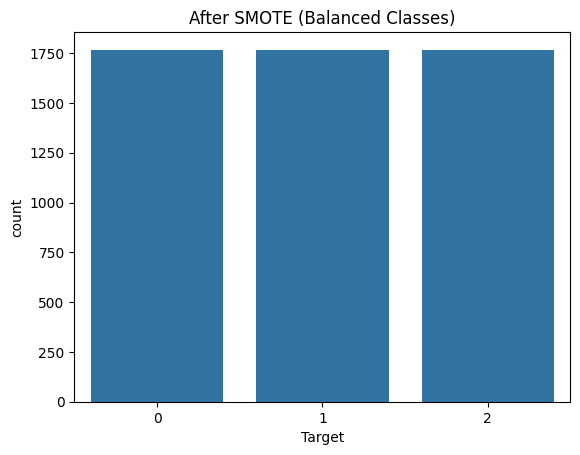

In [98]:
sns.countplot(x=y_train_resampled)
plt.title("After SMOTE (Balanced Classes)")
plt.show()

Define evaluation function + results list

In [99]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []  # initialize BEFORE models

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n{name} Results:")
    print("Accuracy:", acc)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

1. KNN

In [100]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

evaluate_model(
    "KNN (All Features)",
    knn,
    X_train_resampled,
    X_test_scaled,
    y_train_resampled,
    y_test
)


KNN (All Features) Results:
Accuracy: 0.5310734463276836


2. DECISION TREE

In [101]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

evaluate_model(
    "Decision Tree (All Features)",
    dt,
    X_train_resampled,
    X_test_scaled,
    y_train_resampled,
    y_test
)


Decision Tree (All Features) Results:
Accuracy: 0.6632768361581921


3. NAIVE BAYES

In [102]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

evaluate_model(
    "Naive Bayes (All Features)",
    nb,
    X_train_resampled,
    X_test_scaled,
    y_train_resampled,
    y_test
)


Naive Bayes (All Features) Results:
Accuracy: 0.6610169491525424


4. RANDOM FOREST

In [103]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

evaluate_model(
    "Random Forest (All Features)",
    rf,
    X_train_resampled,
    X_test_scaled,
    y_train_resampled,
    y_test
)


Random Forest (All Features) Results:
Accuracy: 0.7694915254237288


5. LOGISTIC REGRESSION

In [104]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

evaluate_model(
    "Logistic Regression (All Features)",
    lr,
    X_train_resampled,
    X_test_scaled,
    y_train_resampled,
    y_test
)


Logistic Regression (All Features) Results:
Accuracy: 0.7084745762711865


6. XGBOOST

In [105]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

evaluate_model(
    "XGBoost (All Features)",
    xgb,
    X_train_resampled,
    X_test_scaled,
    y_train_resampled,
    y_test
)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:30:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost (All Features) Results:
Accuracy: 0.7740112994350282


7. NEURAL NETWORK (MLP)

In [106]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300, random_state=42)

evaluate_model(
    "Neural Network (All Features)",
    mlp,
    X_train_resampled,
    X_test_scaled,
    y_train_resampled,
    y_test
)


Neural Network (All Features) Results:
Accuracy: 0.6937853107344633


8. GRADIENT BOOSTING

In [107]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

evaluate_model(
    "Gradient Boosting (All Features)",
    gb,
    X_train_resampled,
    X_test_scaled,
    y_train_resampled,
    y_test
)


Gradient Boosting (All Features) Results:
Accuracy: 0.7548022598870057


9. SVM

In [108]:
from sklearn.svm import SVC

svm = SVC(probability=True)

evaluate_model(
    "SVM (All Features)",
    svm,
    X_train_resampled,
    X_test_scaled,
    y_train_resampled,
    y_test
)


SVM (All Features) Results:
Accuracy: 0.7242937853107345


10. LIGHTGBM

In [109]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier()

evaluate_model(
    "LightGBM (All Features)",
    lgbm,
    X_train_resampled,
    X_test_scaled,
    y_train_resampled,
    y_test
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002382 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9779
[LightGBM] [Info] Number of data points in the train set: 5301, number of used features: 49
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612

LightGBM (All Features) Results:
Accuracy: 0.7672316384180791


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [110]:
for res in results:
    print(f"Model: {res['Model']}")
    print(f"Accuracy: {res['Accuracy']:.4f}")
    print(f"Precision: {res['Precision']:.4f}")
    print(f"Recall: {res['Recall']:.4f}")
    print(f"F1 Score: {res['F1 Score']:.4f}")
    print("-" * 40)

Model: KNN (All Features)
Accuracy: 0.5311
Precision: 0.6532
Recall: 0.5311
F1 Score: 0.5572
----------------------------------------
Model: Decision Tree (All Features)
Accuracy: 0.6633
Precision: 0.6764
Recall: 0.6633
F1 Score: 0.6690
----------------------------------------
Model: Naive Bayes (All Features)
Accuracy: 0.6610
Precision: 0.6744
Recall: 0.6610
F1 Score: 0.6669
----------------------------------------
Model: Random Forest (All Features)
Accuracy: 0.7695
Precision: 0.7643
Recall: 0.7695
F1 Score: 0.7646
----------------------------------------
Model: Logistic Regression (All Features)
Accuracy: 0.7085
Precision: 0.7531
Recall: 0.7085
F1 Score: 0.7240
----------------------------------------
Model: XGBoost (All Features)
Accuracy: 0.7740
Precision: 0.7683
Recall: 0.7740
F1 Score: 0.7695
----------------------------------------
Model: Neural Network (All Features)
Accuracy: 0.6938
Precision: 0.6925
Recall: 0.6938
F1 Score: 0.6931
----------------------------------------
Mod

SORT RESULTS

In [111]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="F1 Score", ascending=False)
results_df.reset_index(drop=True, inplace=True)

print(results_df)

                                Model  Accuracy  Precision    Recall  F1 Score
0              XGBoost (All Features)  0.774011   0.768253  0.774011  0.769502
1        Random Forest (All Features)  0.769492   0.764273  0.769492  0.764608
2             LightGBM (All Features)  0.767232   0.761363  0.767232  0.762841
3    Gradient Boosting (All Features)  0.754802   0.751337  0.754802  0.752426
4                  SVM (All Features)  0.724294   0.739637  0.724294  0.730372
5  Logistic Regression (All Features)  0.708475   0.753128  0.708475  0.724049
6       Neural Network (All Features)  0.693785   0.692482  0.693785  0.693124
7        Decision Tree (All Features)  0.663277   0.676391  0.663277  0.668953
8          Naive Bayes (All Features)  0.661017   0.674405  0.661017  0.666871
9                  KNN (All Features)  0.531073   0.653221  0.531073  0.557227


VISUALIZATION

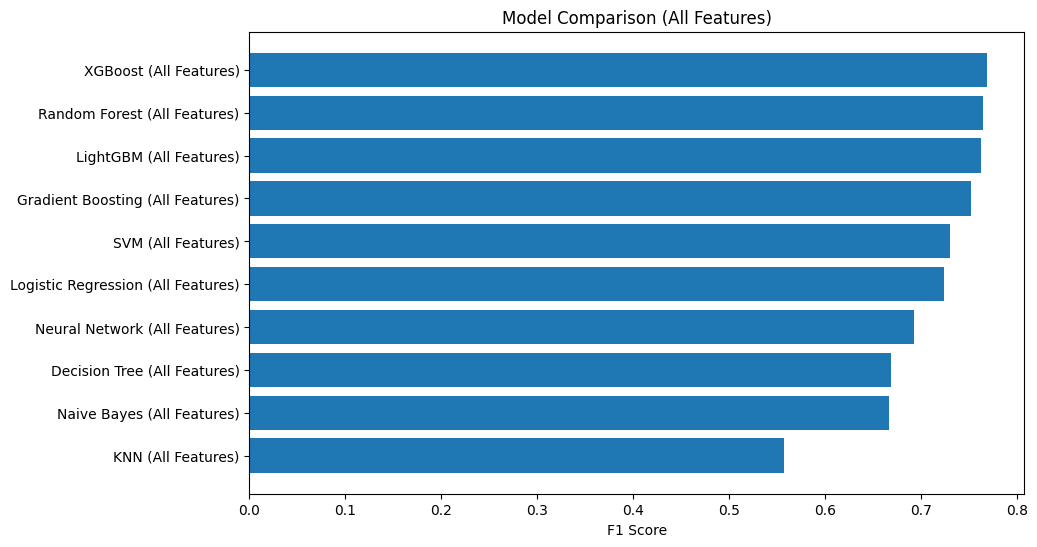

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(results_df["Model"], results_df["F1 Score"])

plt.xlabel("F1 Score")
plt.title("Model Comparison (All Features)")
plt.gca().invert_yaxis()

plt.show()

In [113]:
top_models = results_df["Model"].head(3).tolist()

print("Top 3 Models:", top_models)

Top 3 Models: ['XGBoost (All Features)', 'Random Forest (All Features)', 'LightGBM (All Features)']


In [114]:
top_2_models = results_df["Model"].head(2).tolist()

print("Top 2 Models:", top_2_models)

Top 2 Models: ['XGBoost (All Features)', 'Random Forest (All Features)']


In [115]:
print(results_df.head(5))

                              Model  Accuracy  Precision    Recall  F1 Score
0            XGBoost (All Features)  0.774011   0.768253  0.774011  0.769502
1      Random Forest (All Features)  0.769492   0.764273  0.769492  0.764608
2           LightGBM (All Features)  0.767232   0.761363  0.767232  0.762841
3  Gradient Boosting (All Features)  0.754802   0.751337  0.754802  0.752426
4                SVM (All Features)  0.724294   0.739637  0.724294  0.730372


VOTING (TOP 2 MODELS)

XGBoost + Random Forest

In [116]:
from sklearn.ensemble import VotingClassifier

voting_2_all = VotingClassifier(
    estimators=[
        ('xgb', xgb),
        ('rf', rf)
    ],
    voting='soft'
)

evaluate_model(
    "Voting (XGB + RF) (All Features)",
    voting_2_all,
    X_train_resampled,
    X_test_scaled,
    y_train_resampled,
    y_test
)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:30:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Voting (XGB + RF) (All Features) Results:
Accuracy: 0.7672316384180791


VOTING (TOP 3 MODELS)
XGB + RF + LGBM

In [117]:
voting_3_all = VotingClassifier(
    estimators=[
        ('xgb', xgb),
        ('rf', rf),
        ('lgbm', lgbm)
    ],
    voting='soft'
)

evaluate_model(
    "Voting (XGB + RF + LGBM) (All Features)",
    voting_3_all,
    X_train_resampled,
    X_test_scaled,
    y_train_resampled,
    y_test
)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:31:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002494 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9779
[LightGBM] [Info] Number of data points in the train set: 5301, number of used features: 49
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612

Voting (XGB + RF + LGBM) (All Features) Results:
Accuracy: 0.7694915254237288


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


STACKING (TOP 2 MODELS)
XGB + RF

In [118]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack_2_all = StackingClassifier(
    estimators=[
        ('xgb', xgb),
        ('rf', rf)
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

evaluate_model(
    "Stacking (XGB + RF) (All Features)",
    stack_2_all,
    X_train_resampled,
    X_test_scaled,
    y_train_resampled,
    y_test
)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:31:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:31:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:31:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:31:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


Stacking (XGB + RF) (All Features) Results:
Accuracy: 0.7649717514124293


STACKING (TOP 3 MODELS)

XGB + RF + LGBM

In [119]:
stack_3_all = StackingClassifier(
    estimators=[
        ('xgb', xgb),
        ('rf', rf),
        ('lgbm', lgbm)
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

evaluate_model(
    "Stacking (XGB + RF + LGBM) (All Features)",
    stack_3_all,
    X_train_resampled,
    X_test_scaled,
    y_train_resampled,
    y_test
)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:31:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001758 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9779
[LightGBM] [Info] Number of data points in the train set: 5301, number of used features: 49
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:31:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:31:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:31:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:31:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001377 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9783
[LightGBM] [Info] Number of data points in the train set: 4240, number of used features: 49
[LightGBM] [Info] Start training from score -1.098141
[LightGBM] [Info] Start training from score -1.098848
[LightGBM] [Info] Start training from score -1.098848


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001474 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8899
[LightGBM] [Info] Number of data points in the train set: 4241, number of used features: 49
[LightGBM] [Info] Start training from score -1.099084
[LightGBM] [Info] Start training from score -1.098377
[LightGBM] [Info] Start training from score -1.098377


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001382 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8802
[LightGBM] [Info] Number of data points in the train set: 4241, number of used features: 49
[LightGBM] [Info] Start training from score -1.098377
[LightGBM] [Info] Start training from score -1.099084
[LightGBM] [Info] Start training from score -1.098377

Stacking (XGB + RF + LGBM) (All Features) Results:
Accuracy: 0.768361581920904


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [120]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)
results_df.reset_index(drop=True, inplace=True)

print(results_df)

                                        Model  Accuracy  Precision    Recall  \
0                      XGBoost (All Features)  0.774011   0.768253  0.774011   
1   Stacking (XGB + RF + LGBM) (All Features)  0.768362   0.763572  0.768362   
2     Voting (XGB + RF + LGBM) (All Features)  0.769492   0.763272  0.769492   
3                Random Forest (All Features)  0.769492   0.764273  0.769492   
4                     LightGBM (All Features)  0.767232   0.761363  0.767232   
5            Voting (XGB + RF) (All Features)  0.767232   0.761246  0.767232   
6          Stacking (XGB + RF) (All Features)  0.764972   0.760501  0.764972   
7            Gradient Boosting (All Features)  0.754802   0.751337  0.754802   
8                          SVM (All Features)  0.724294   0.739637  0.724294   
9          Logistic Regression (All Features)  0.708475   0.753128  0.708475   
10              Neural Network (All Features)  0.693785   0.692482  0.693785   
11               Decision Tree (All Feat